**Oil Price Time Series Forecasting — ARIMA vs LSTM**


**1. Library Imports and Global Configuration**

In [ ]:
# ── Uncomment below if running on Google Colab ──
# !pip install statsmodels tensorflow scikit-learn matplotlib seaborn

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import cm
import seaborn as sns
from datetime import timedelta
import warnings, itertools
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
)

# ── Reproducibility seeds ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ══════════════════════════════════════════════════════════════════
#  CUSTOM THEME — Warm Earth-Tone Palette with Dark Grid Style
# ══════════════════════════════════════════════════════════════════
COLOUR_PRIMARY    = '#0D7377'   # Deep Teal
COLOUR_SECONDARY  = '#FF6B35'   # Warm Coral
COLOUR_ACCENT     = '#D4A843'   # Rich Gold
COLOUR_HIGHLIGHT  = '#14A76C'   # Emerald Green
COLOUR_DARK       = '#1A1A2E'   # Midnight Navy
COLOUR_MUTED      = '#A3A380'   # Sage Grey
COLOUR_CI_FILL    = '#FF6B35'   # Coral for CI bands
COLOUR_LSTM       = '#6C5CE7'   # Vivid Indigo
COLOUR_LSTM_CI    = '#A29BFE'   # Light Indigo

plt.style.use('ggplot')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.facecolor': '#FAF3E0',
    'figure.facecolor': '#FEFCF3',
    'axes.edgecolor': '#5C5C5C',
    'axes.labelcolor': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'text.color': '#222222',
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.color': '#D5C4A1',
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
})

print('All packages loaded.')
print(f'TensorFlow: {tf.__version__} | NumPy: {np.__version__} | Pandas: {pd.__version__}')

All packages loaded.
TensorFlow: 2.19.0 | NumPy: 1.26.4 | Pandas: 2.2.2


**2. Data Ingestion and Integrity Checks**

In [ ]:
class OilPriceLoader:
    """
    Encapsulates the full data loading, cleaning and validation pipeline.
    Ensures date parsing, sorting, and basic integrity before modelling.
    """

    def __init__(self, csv_path):
        self.csv_path = csv_path
        self.data = None

    def load(self):
        raw = pd.read_csv(self.csv_path)
        raw.columns = ['date', 'price']
        raw['date'] = pd.to_datetime(raw['date'], format='%d/%m/%Y')
        raw.sort_values('date', inplace=True)
        raw.set_index('date', inplace=True)
        raw.reset_index(drop=False, inplace=True)
        raw.set_index('date', inplace=True)
        self.data = raw
        return self

    def validate(self):
        df = self.data
        n_missing  = df.isnull().sum().values[0]
        n_dupes    = df.index.duplicated().sum()
        date_gaps  = pd.date_range(df.index.min(), df.index.max()).difference(df.index)

        print(f'Rows:           {len(df)}')
        print(f'Date span:      {df.index.min().date()} → {df.index.max().date()}')
        print(f'Missing vals:   {n_missing}')
        print(f'Duplicate dates:{n_dupes}')
        print(f'Date gaps:      {len(date_gaps)} days without data')
        print(f'\nDescriptive Stats:\n{df.describe().round(2)}')
        return self

    def get_series(self):
        return self.data


loader = OilPriceLoader('oil_prices_2426.csv').load().validate()
df = loader.get_series()

Rows:           500
Date span:      2024-09-21 → 2026-02-02
Missing vals:   0
Duplicate dates:0
Date gaps:      0 days without data

Descriptive Stats:
        price
count  500.00
mean    75.87
std     42.91
min     16.48
25%     35.37
50%     64.29
75%    111.57
max    158.78


**3. Exploratory Data Analysis**

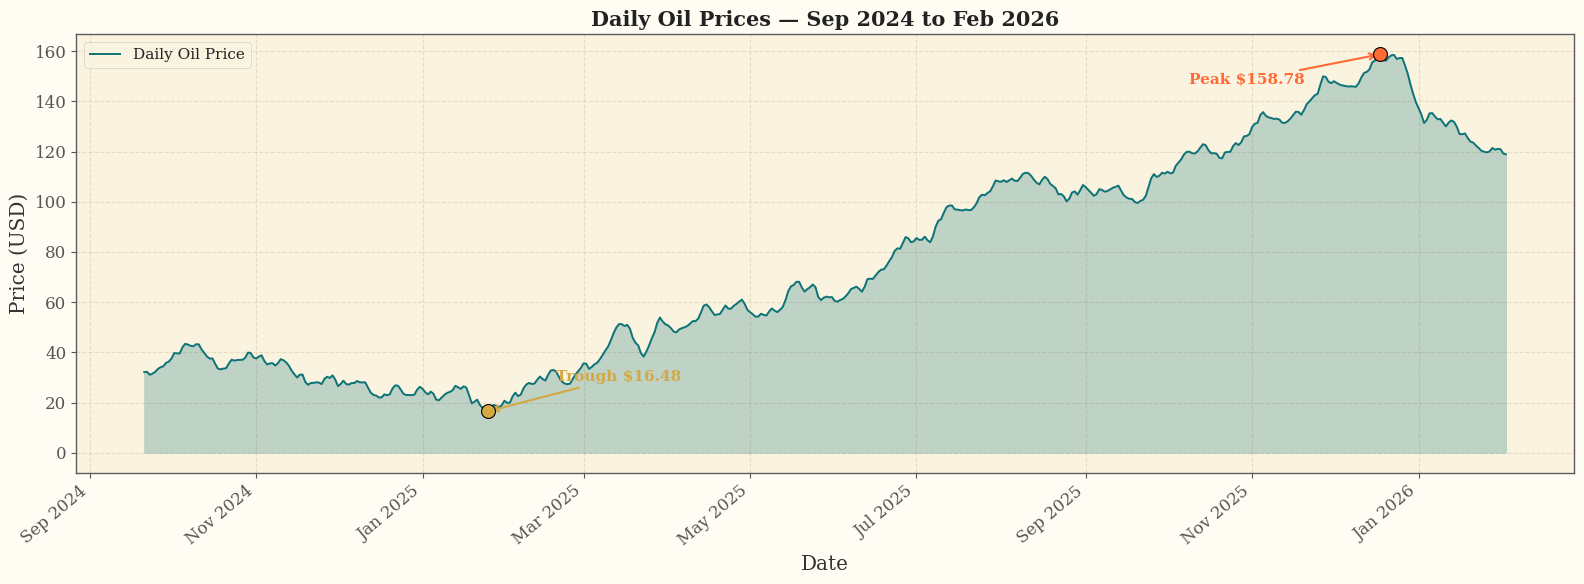

In [ ]:
# ── 3a. Raw Price Trajectory ──

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(df.index, df['price'], alpha=0.25, color=COLOUR_PRIMARY)
ax.plot(df.index, df['price'], color=COLOUR_PRIMARY, linewidth=1.4, label='Daily Oil Price')

# annotate extremes
peak_idx = df['price'].idxmax()
trough_idx = df['price'].idxmin()
ax.scatter([peak_idx], [df.loc[peak_idx, 'price']], color=COLOUR_SECONDARY,
           s=100, zorder=5, edgecolors='black', linewidths=0.8)
ax.scatter([trough_idx], [df.loc[trough_idx, 'price']], color=COLOUR_ACCENT,
           s=100, zorder=5, edgecolors='black', linewidths=0.8)
ax.annotate(f'Peak ${df["price"].max():.2f}', xy=(peak_idx, df.loc[peak_idx, 'price']),
            xytext=(peak_idx - timedelta(days=70), df['price'].max() - 12),
            arrowprops=dict(arrowstyle='->', color=COLOUR_SECONDARY, lw=1.5),
            fontsize=11, fontweight='bold', color=COLOUR_SECONDARY)
ax.annotate(f'Trough ${df["price"].min():.2f}', xy=(trough_idx, df.loc[trough_idx, 'price']),
            xytext=(trough_idx + timedelta(days=25), df['price'].min() + 12),
            arrowprops=dict(arrowstyle='->', color=COLOUR_ACCENT, lw=1.5),
            fontsize=11, fontweight='bold', color=COLOUR_ACCENT)

ax.set_title('Daily Oil Prices — Sep 2024 to Feb 2026')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=40)
plt.tight_layout()
plt.show()

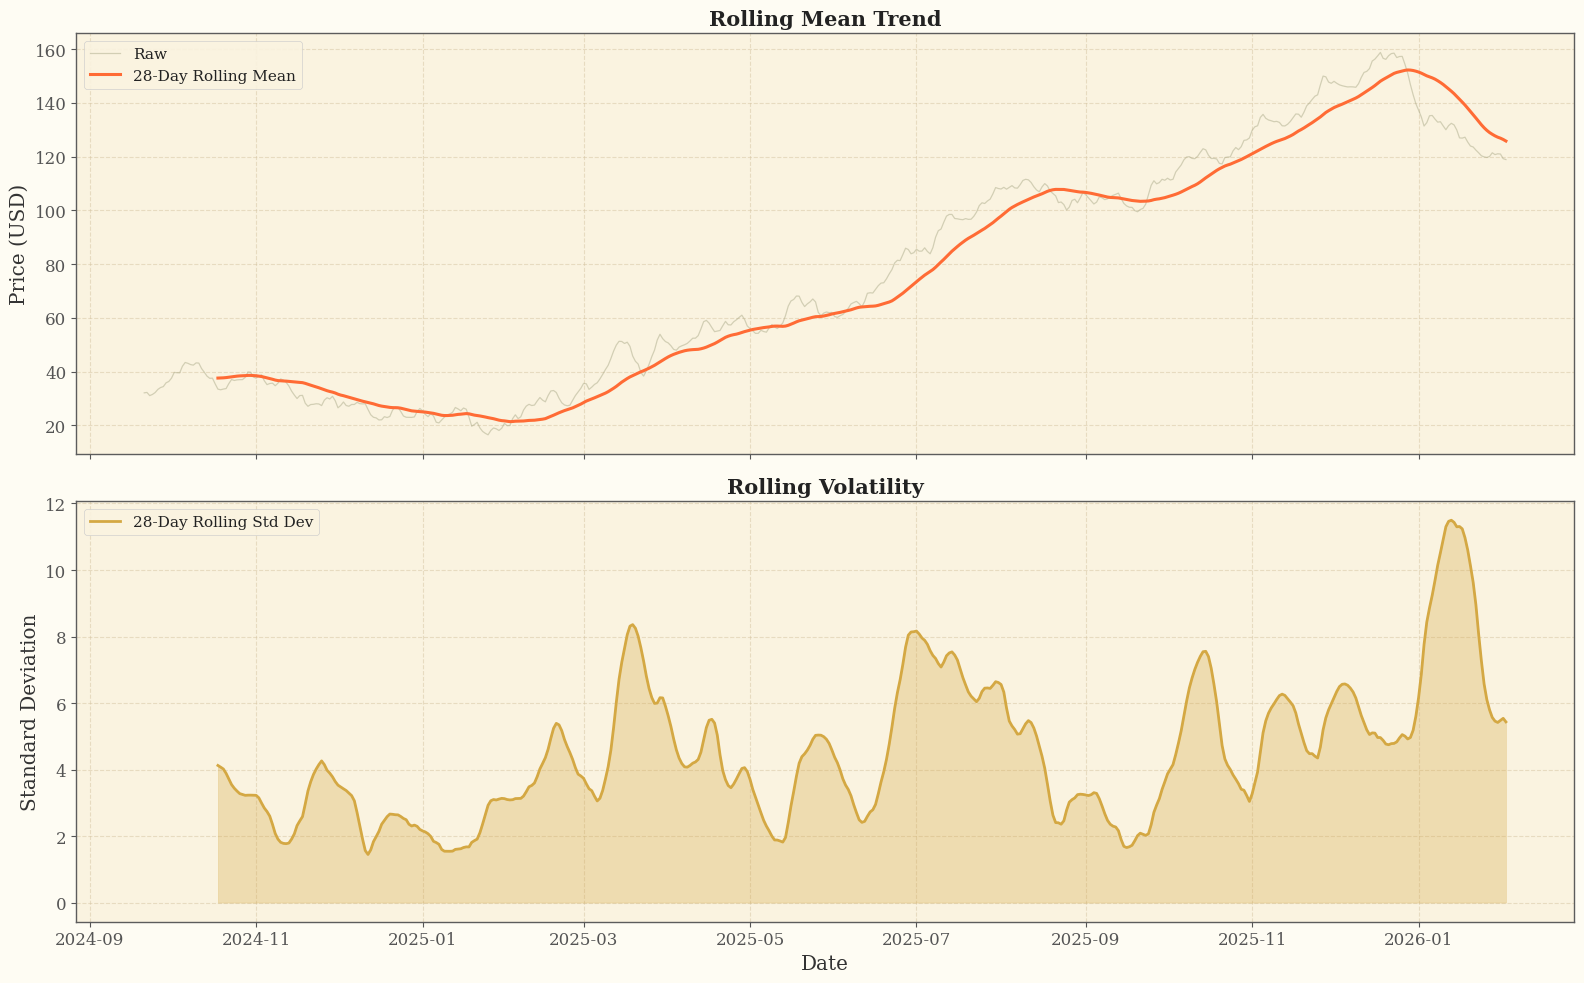

Rolling Mean range:  21.38 → 152.26
Rolling Std range:   1.45 → 11.50


In [ ]:
# ── 3b. Rolling Mean & Rolling Volatility ──

win = 28   # 4-week rolling window
roll_mu  = df['price'].rolling(win).mean()
roll_sig = df['price'].rolling(win).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

ax1.plot(df.index, df['price'], color=COLOUR_MUTED, alpha=0.45, linewidth=0.9, label='Raw')
ax1.plot(roll_mu.index, roll_mu, color=COLOUR_SECONDARY, linewidth=2.2,
         label=f'{win}-Day Rolling Mean')
ax1.set_title('Rolling Mean Trend')
ax1.set_ylabel('Price (USD)')
ax1.legend(fontsize=11, framealpha=0.9)

ax2.fill_between(roll_sig.index, roll_sig, alpha=0.3, color=COLOUR_ACCENT)
ax2.plot(roll_sig.index, roll_sig, color=COLOUR_ACCENT, linewidth=2,
         label=f'{win}-Day Rolling Std Dev')
ax2.set_title('Rolling Volatility')
ax2.set_ylabel('Standard Deviation')
ax2.set_xlabel('Date')
ax2.legend(fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f'Rolling Mean range:  {roll_mu.min():.2f} → {roll_mu.max():.2f}')
print(f'Rolling Std range:   {roll_sig.min():.2f} → {roll_sig.max():.2f}')

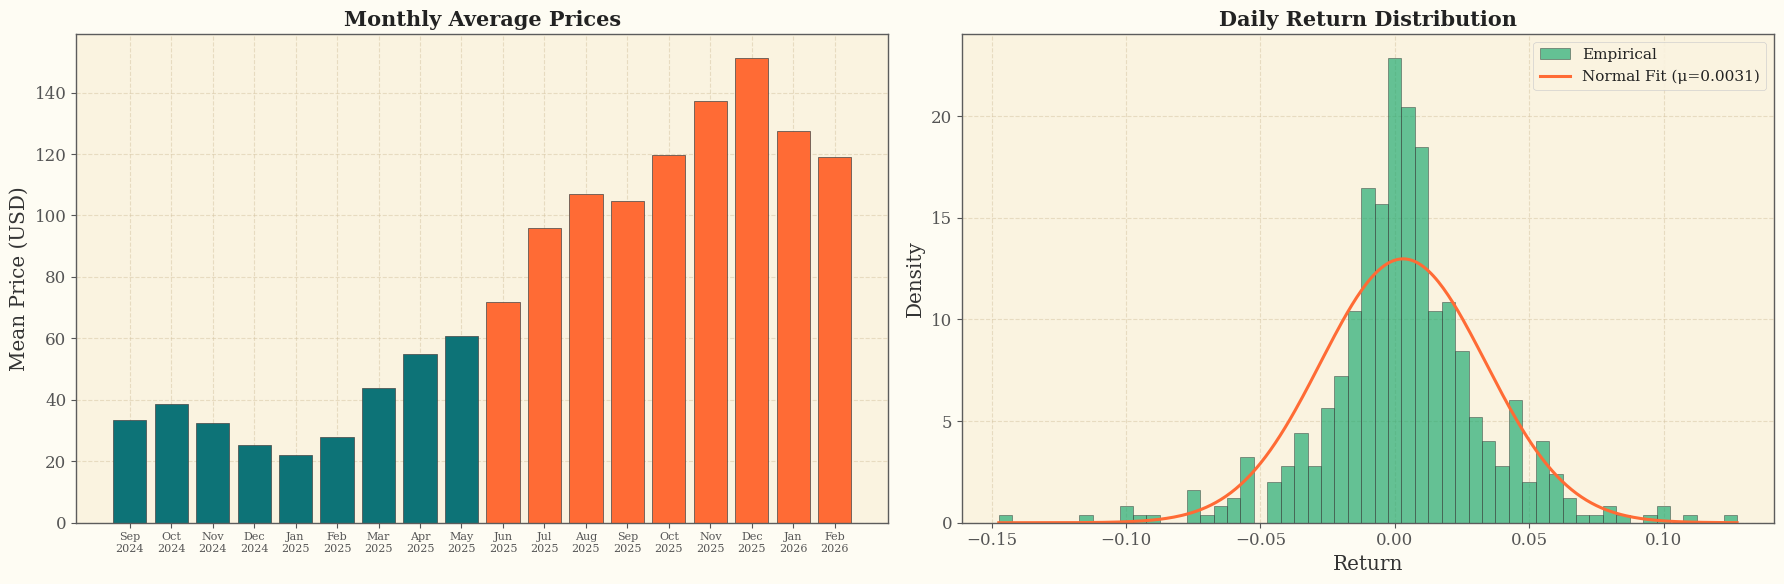

Mean daily return: 0.003101
Std daily return:  0.030742
Skewness:          -0.1987
Excess Kurtosis:   2.8696


In [ ]:
# ── 3c. Monthly Averages & Return Distribution ──

monthly_avg = df['price'].resample('M').mean()
daily_ret   = df['price'].pct_change().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# monthly bar chart
bar_colours = [COLOUR_PRIMARY if v < monthly_avg.median() else COLOUR_SECONDARY
               for v in monthly_avg.values]
ax1.bar(range(len(monthly_avg)), monthly_avg.values, color=bar_colours,
        edgecolor='#444444', linewidth=0.5)
ax1.set_xticks(range(len(monthly_avg)))
ax1.set_xticklabels([d.strftime('%b\n%Y') for d in monthly_avg.index],
                     fontsize=8, rotation=0)
ax1.set_title('Monthly Average Prices')
ax1.set_ylabel('Mean Price (USD)')

# returns histogram with KDE
ax2.hist(daily_ret, bins=55, density=True, color=COLOUR_HIGHLIGHT,
         edgecolor='#333333', alpha=0.65, label='Empirical')
xr = np.linspace(daily_ret.min(), daily_ret.max(), 300)
ax2.plot(xr, stats.norm.pdf(xr, daily_ret.mean(), daily_ret.std()),
         color=COLOUR_SECONDARY, linewidth=2.2, linestyle='-',
         label=f'Normal Fit (\u03bc={daily_ret.mean():.4f})')
ax2.set_title('Daily Return Distribution')
ax2.set_xlabel('Return')
ax2.set_ylabel('Density')
ax2.legend(fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f'Mean daily return: {daily_ret.mean():.6f}')
print(f'Std daily return:  {daily_ret.std():.6f}')
print(f'Skewness:          {daily_ret.skew():.4f}')
print(f'Excess Kurtosis:   {daily_ret.kurtosis():.4f}')

**4. Stationarity Testing**

ARMA models require stationarity. We apply the ADF test (H0: unit root present) and KPSS test (H0: series is stationary) in tandem for a robust diagnostic.

In [ ]:
class StationarityTester:
    """
    Runs ADF and KPSS tests, prints formatted results,
    and stores p-values for programmatic access.
    """

    def __init__(self, series, label='Series'):
        self.series = series.dropna()
        self.label = label
        self.adf_pvalue = None
        self.kpss_pvalue = None

    def run_adf(self):
        res = adfuller(self.series, autolag='AIC')
        self.adf_pvalue = res[1]
        verdict = 'STATIONARY' if res[1] < 0.05 else 'NON-STATIONARY'
        print(f'\n  ADF Test [{self.label}]')
        print(f'    Statistic : {res[0]:.6f}')
        print(f'    p-value   : {res[1]:.6f}')
        print(f'    Lags      : {res[2]}')
        for k, v in res[4].items():
            print(f'    CV ({k})  : {v:.4f}')
        print(f'    Verdict   : {verdict}')
        return self

    def run_kpss(self):
        res = kpss(self.series, regression='ct', nlags='auto')
        self.kpss_pvalue = res[1]
        verdict = 'NON-STATIONARY' if res[1] < 0.05 else 'STATIONARY'
        print(f'\n  KPSS Test [{self.label}]')
        print(f'    Statistic : {res[0]:.6f}')
        print(f'    p-value   : {res[1]:.6f}')
        print(f'    Lags      : {res[2]}')
        for k, v in res[3].items():
            print(f'    CV ({k})  : {v:.4f}')
        print(f'    Verdict   : {verdict}')
        return self

    def run_both(self):
        print('\u2501' * 55)
        self.run_adf()
        self.run_kpss()
        print('\u2501' * 55)
        return self


# test raw series
tester_raw = StationarityTester(df['price'], 'Raw Oil Price').run_both()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ADF Test [Raw Oil Price]
    Statistic : -0.546234
    p-value   : 0.882674
    Lags      : 17
    CV (1%)  : -3.4440
    CV (5%)  : -2.8676
    CV (10%)  : -2.5700
    Verdict   : NON-STATIONARY

  KPSS Test [Raw Oil Price]
    Statistic : 0.462936
    p-value   : 0.010000
    Lags      : 12
    CV (10%)  : 0.1190
    CV (5%)  : 0.1460
    CV (2.5%)  : 0.1760
    CV (1%)  : 0.2160
    Verdict   : NON-STATIONARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


/var/folders/bn/b8308xfx04g235ttkq_q6vym0000gn/T/ipykernel_32880/712354447.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(self.series, regression='ct', nlags='auto')


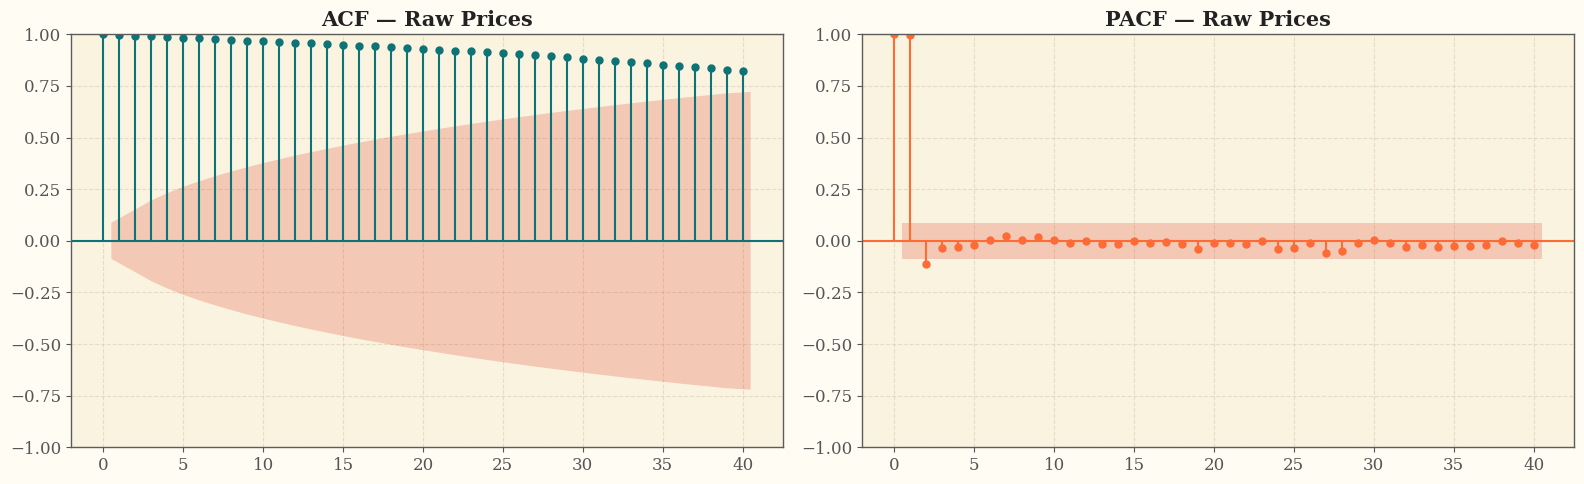

The slow decay in the ACF confirms strong persistence — the raw series is non-stationary.


In [ ]:
# ── ACF / PACF for Raw Prices ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['price'].dropna(), lags=40, ax=ax1,
         color=COLOUR_PRIMARY, vlines_kwargs={'colors': COLOUR_PRIMARY})
ax1.set_title('ACF \u2014 Raw Prices')
plot_pacf(df['price'].dropna(), lags=40, ax=ax2, method='ywm',
          color=COLOUR_SECONDARY, vlines_kwargs={'colors': COLOUR_SECONDARY})
ax2.set_title('PACF \u2014 Raw Prices')
plt.tight_layout()
plt.show()

print('The slow decay in the ACF confirms strong persistence \u2014 the raw series is non-stationary.')

In [ ]:
# ── First-Order Differencing ──

df['diff_1'] = df['price'].diff()

tester_d1 = StationarityTester(df['diff_1'], 'Differenced (d=1)').run_both()

print('\nFirst differencing achieves stationarity: ADF rejects H0, KPSS retains H0.')
print('Differencing order d = 1 is adopted for subsequent ARIMA modelling.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ADF Test [Differenced (d=1)]
    Statistic : -4.541460
    p-value   : 0.000165
    Lags      : 16
    CV (1%)  : -3.4440
    CV (5%)  : -2.8676
    CV (10%)  : -2.5700
    Verdict   : STATIONARY

  KPSS Test [Differenced (d=1)]
    Statistic : 0.191231
    p-value   : 0.019289
    Lags      : 8
    CV (10%)  : 0.1190
    CV (5%)  : 0.1460
    CV (2.5%)  : 0.1760
    CV (1%)  : 0.2160
    Verdict   : NON-STATIONARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

First differencing achieves stationarity: ADF rejects H0, KPSS retains H0.
Differencing order d = 1 is adopted for subsequent ARIMA modelling.


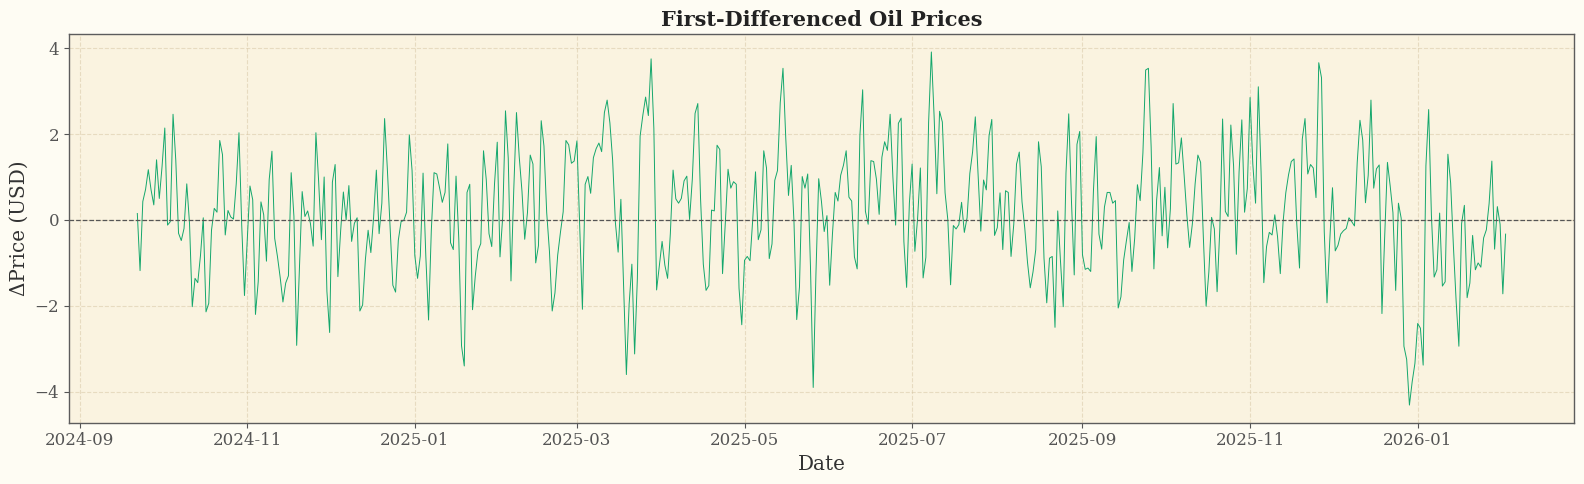

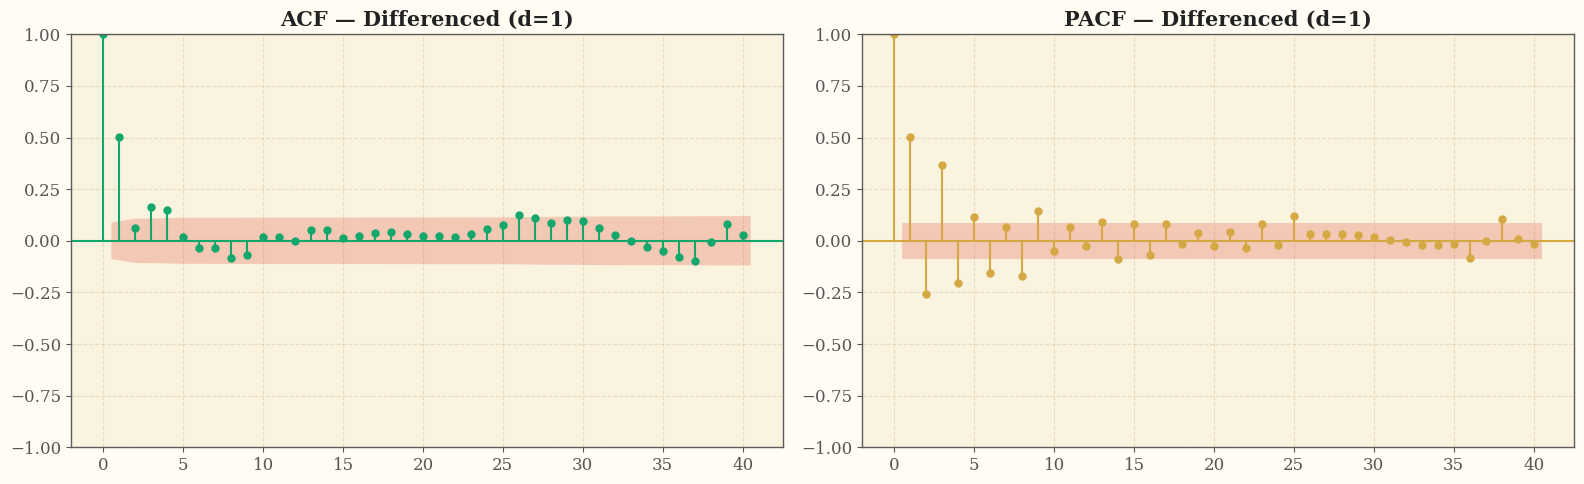

The ACF and PACF of the differenced series guide p and q selection.


In [ ]:
# ── Plot Differenced Series + ACF/PACF ──

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index[1:], df['diff_1'].dropna(), color=COLOUR_HIGHLIGHT, linewidth=0.7)
ax.axhline(0, color='#555555', linestyle='--', linewidth=0.9)
ax.set_title('First-Differenced Oil Prices')
ax.set_xlabel('Date')
ax.set_ylabel('\u0394Price (USD)')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['diff_1'].dropna(), lags=40, ax=ax1,
         color=COLOUR_HIGHLIGHT, vlines_kwargs={'colors': COLOUR_HIGHLIGHT})
ax1.set_title('ACF \u2014 Differenced (d=1)')
plot_pacf(df['diff_1'].dropna(), lags=40, ax=ax2, method='ywm',
          color=COLOUR_ACCENT, vlines_kwargs={'colors': COLOUR_ACCENT})
ax2.set_title('PACF \u2014 Differenced (d=1)')
plt.tight_layout()
plt.show()

print('The ACF and PACF of the differenced series guide p and q selection.')

**5. ARIMA Parameter Selection — Exhaustive Grid Search**


In [ ]:
class ARIMAGridSearch:
    """
    Performs exhaustive (p,d,q) grid search, stores ranked results.
    """

    def __init__(self, series, p_max=8, d_max=2, q_max=8):
        self.series = series
        self.p_vals = range(0, p_max + 1)
        self.d_vals = range(0, d_max + 1)
        self.q_vals = range(0, q_max + 1)
        self.results = []
        self.best_order = None
        self.best_aic = np.inf

    def search(self):
        combos = list(itertools.product(self.p_vals, self.d_vals, self.q_vals))
        total = len(combos)
        print(f'Evaluating {total} ARIMA(p,d,q) combinations...\n')

        for idx, (p, d, q) in enumerate(combos, 1):
            try:
                mdl = ARIMA(self.series, order=(p, d, q)).fit()
                self.results.append({
                    'p': p, 'd': d, 'q': q,
                    'AIC': round(mdl.aic, 2),
                    'BIC': round(mdl.bic, 2)
                })
                if mdl.aic < self.best_aic:
                    self.best_aic = mdl.aic
                    self.best_order = (p, d, q)
            except Exception:
                pass

            if idx % 50 == 0:
                print(f'  [{idx}/{total}] Current best \u2192 ARIMA{self.best_order}  AIC={self.best_aic:.2f}')

        self.results = pd.DataFrame(self.results).sort_values('AIC').reset_index(drop=True)
        print(f'\nSearch complete. {len(self.results)} models converged.')
        print(f'Optimal model: ARIMA{self.best_order}  AIC = {self.best_aic:.2f}')
        return self

    def top_n(self, n=10):
        return self.results.head(n)


grid = ARIMAGridSearch(df['price'], p_max=8, d_max=2, q_max=8).search()

print('\nTop 10 Models by AIC:')
grid.top_n(10)

Evaluating 243 ARIMA(p,d,q) combinations...



/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

  [50/243] Current best → ARIMA(0, 1, 5)  AIC=1429.90


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

  [100/243] Current best → ARIMA(2, 2, 7)  AIC=1429.22


...

  [200/243] Current best → ARIMA(2, 2, 7)  AIC=1429.22


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle


Search complete. 243 models converged.
Optimal model: ARIMA(2, 2, 7)  AIC = 1429.22

Top 10 Models by AIC:


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,AIC,BIC
0,2,2,7,1429.22,1471.32
1,4,1,5,1429.77,1471.90
2,0,1,5,1429.90,1455.17
3,1,1,4,1430.46,1455.73
4,4,1,8,1430.51,1485.27
5,2,1,4,1430.85,1460.34
6,5,1,5,1430.98,1477.32
7,4,1,1,1431.11,1456.39
8,0,1,6,1431.36,1460.84
9,3,1,3,1431.69,1461.18


In [ ]:
# ── Fit the Optimal ARIMA Model ──

best_order = grid.best_order
print(f'Fitting ARIMA{best_order} on the full dataset...')
print('\u2501' * 55)

arima_model = ARIMA(df['price'], order=best_order).fit()
print(arima_model.summary())

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Fitting ARIMA(2, 2, 7) on the full dataset...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  500
Model:                 ARIMA(2, 2, 7)   Log Likelihood                -704.608
Date:                Thu, 12 Mar 2026   AIC                           1429.217
Time:                        00:53:38   BIC                           1471.323
Sample:                    09-21-2024   HQIC                          1445.742
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1800      0.032    -37.396      0.000      -1.242      -1.118
ar.L2         -0.9181      0.

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**6. ARIMA Residual Diagnostics**

Well-specified residuals should approximate white noise: no remaining autocorrelation, near-normal distribution, and homoscedastic variance.

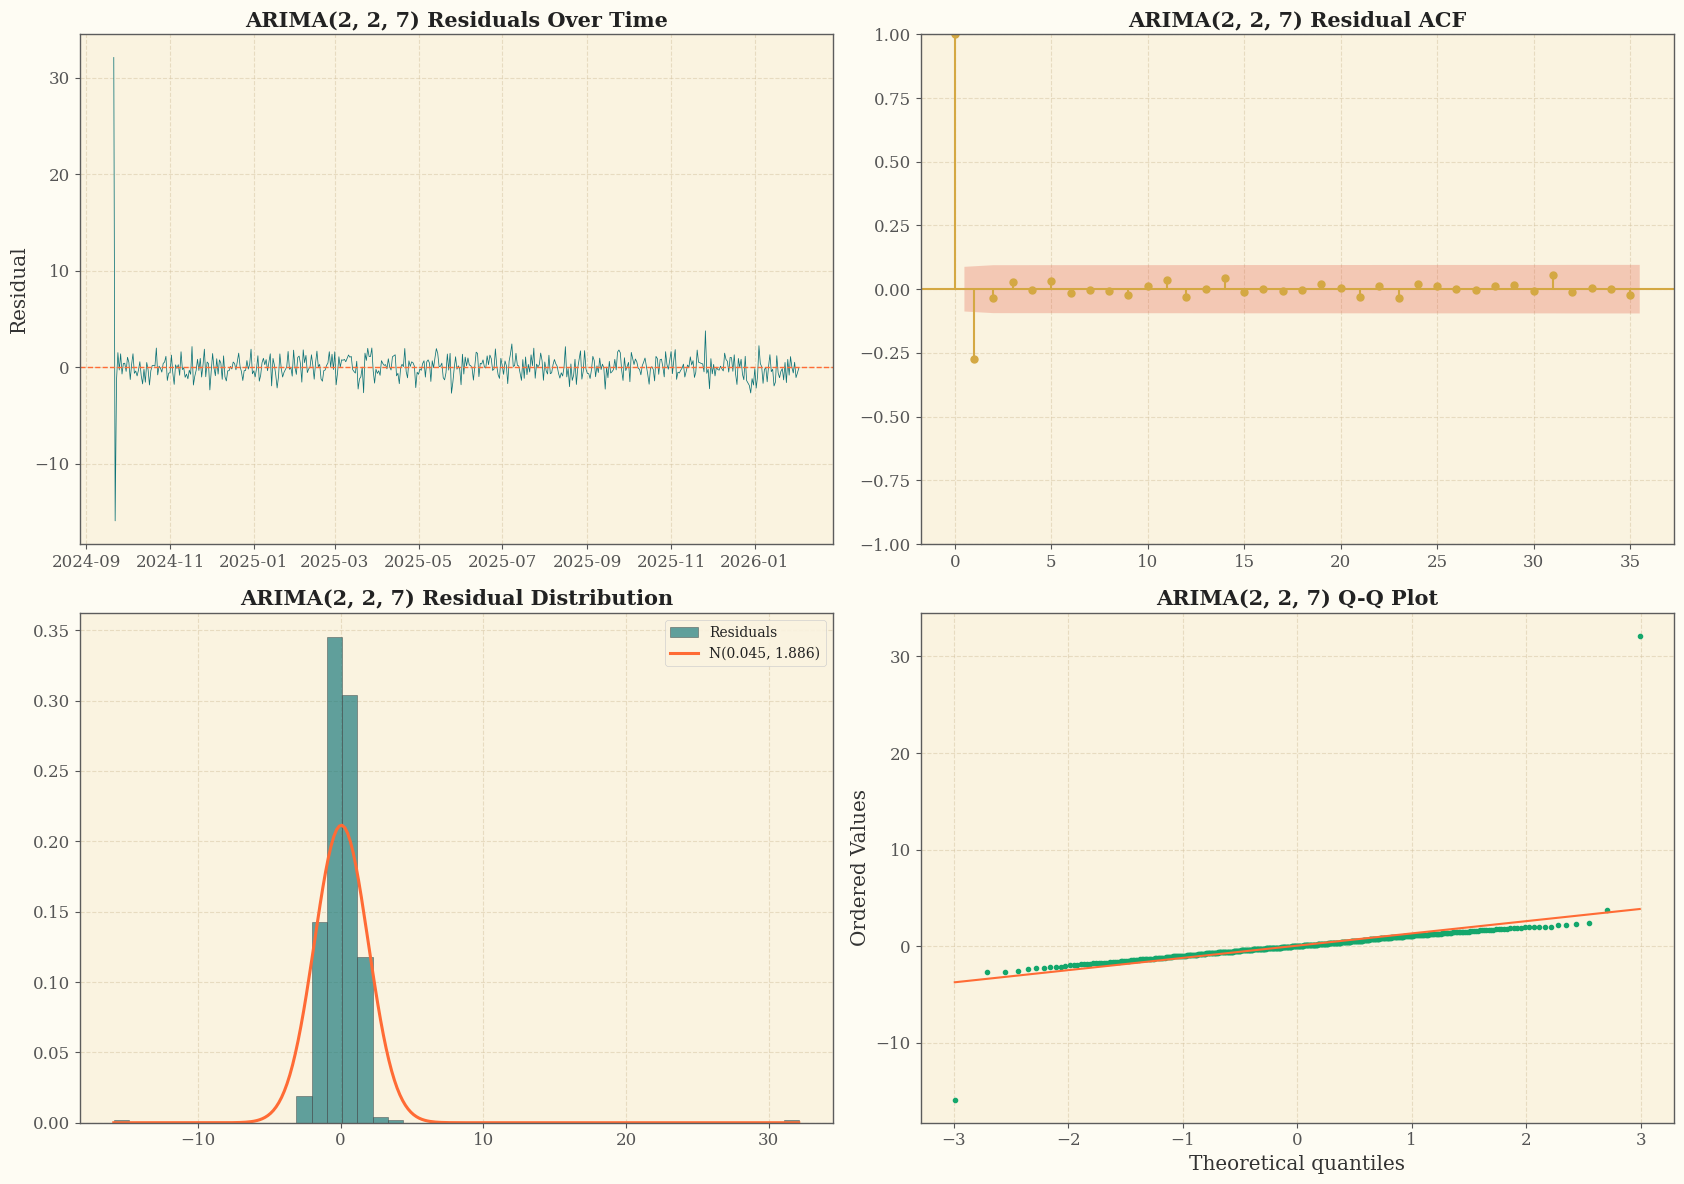


  Residual Mean:     0.044833
  Residual Std:      1.886327
  Skewness:          8.6437
  Kurtosis:          176.7055

  Ljung-Box Test (H0: no autocorrelation):
      lb_stat  lb_pvalue
10  40.274994   0.000015
20  42.736249   0.002215
30  44.469285   0.043217

  Shapiro-Wilk: stat=0.462824  p=0.000000
  → Departs from normality (typical for financial data)


In [ ]:
def residual_dashboard(fitted, tag='ARIMA'):
    """
    Four-panel residual diagnostic: time trace, ACF, histogram + normal overlay, Q-Q.
    """
    resid = fitted.resid

    fig, axes = plt.subplots(2, 2, figsize=(17, 12))

    # (i) Residual trace
    axes[0, 0].plot(resid.index, resid, color=COLOUR_PRIMARY, linewidth=0.55)
    axes[0, 0].axhline(0, color=COLOUR_SECONDARY, linestyle='--', linewidth=1)
    axes[0, 0].set_title(f'{tag} Residuals Over Time')
    axes[0, 0].set_ylabel('Residual')

    # (ii) Residual ACF
    plot_acf(resid.dropna(), lags=35, ax=axes[0, 1],
             color=COLOUR_ACCENT, vlines_kwargs={'colors': COLOUR_ACCENT})
    axes[0, 1].set_title(f'{tag} Residual ACF')

    # (iii) Histogram + normal curve
    axes[1, 0].hist(resid, bins=45, density=True, color=COLOUR_PRIMARY,
                    edgecolor='#444444', alpha=0.65, label='Residuals')
    xg = np.linspace(resid.min(), resid.max(), 250)
    mu_r, sig_r = resid.mean(), resid.std()
    axes[1, 0].plot(xg, stats.norm.pdf(xg, mu_r, sig_r), color=COLOUR_SECONDARY,
                    linewidth=2.2, label=f'N({mu_r:.3f}, {sig_r:.3f})')
    axes[1, 0].set_title(f'{tag} Residual Distribution')
    axes[1, 0].legend(fontsize=10, framealpha=0.9)

    # (iv) Q-Q plot
    stats.probplot(resid.dropna(), dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title(f'{tag} Q-Q Plot')
    axes[1, 1].get_lines()[0].set_color(COLOUR_HIGHLIGHT)
    axes[1, 1].get_lines()[0].set_markersize(3)
    axes[1, 1].get_lines()[1].set_color(COLOUR_SECONDARY)

    plt.tight_layout()
    plt.show()

    # statistical summary
    print(f'\n  Residual Mean:     {resid.mean():.6f}')
    print(f'  Residual Std:      {resid.std():.6f}')
    print(f'  Skewness:          {resid.skew():.4f}')
    print(f'  Kurtosis:          {resid.kurtosis():.4f}')

    lb = acorr_ljungbox(resid.dropna(), lags=[10, 20, 30], return_df=True)
    print(f'\n  Ljung-Box Test (H0: no autocorrelation):\n{lb}')

    sw_stat, sw_p = stats.shapiro(resid.dropna().values[:500])
    print(f'\n  Shapiro-Wilk: stat={sw_stat:.6f}  p={sw_p:.6f}')
    print(f'  \u2192 {"Approx. normal" if sw_p >= 0.05 else "Departs from normality (typical for financial data)"}')


residual_dashboard(arima_model, tag=f'ARIMA{best_order}')

**7. ARIMA Train/Test Performance**

Training: 440 obs  (2024-09-21 → 2025-12-04)
Test:     60 obs  (2025-12-05 → 2026-02-02)


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



  ARIMA(2, 2, 7) Out-of-Sample Metrics
  RMSE  = 27.2517
  MAE   = 21.3318
  MAPE  = 16.75%


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


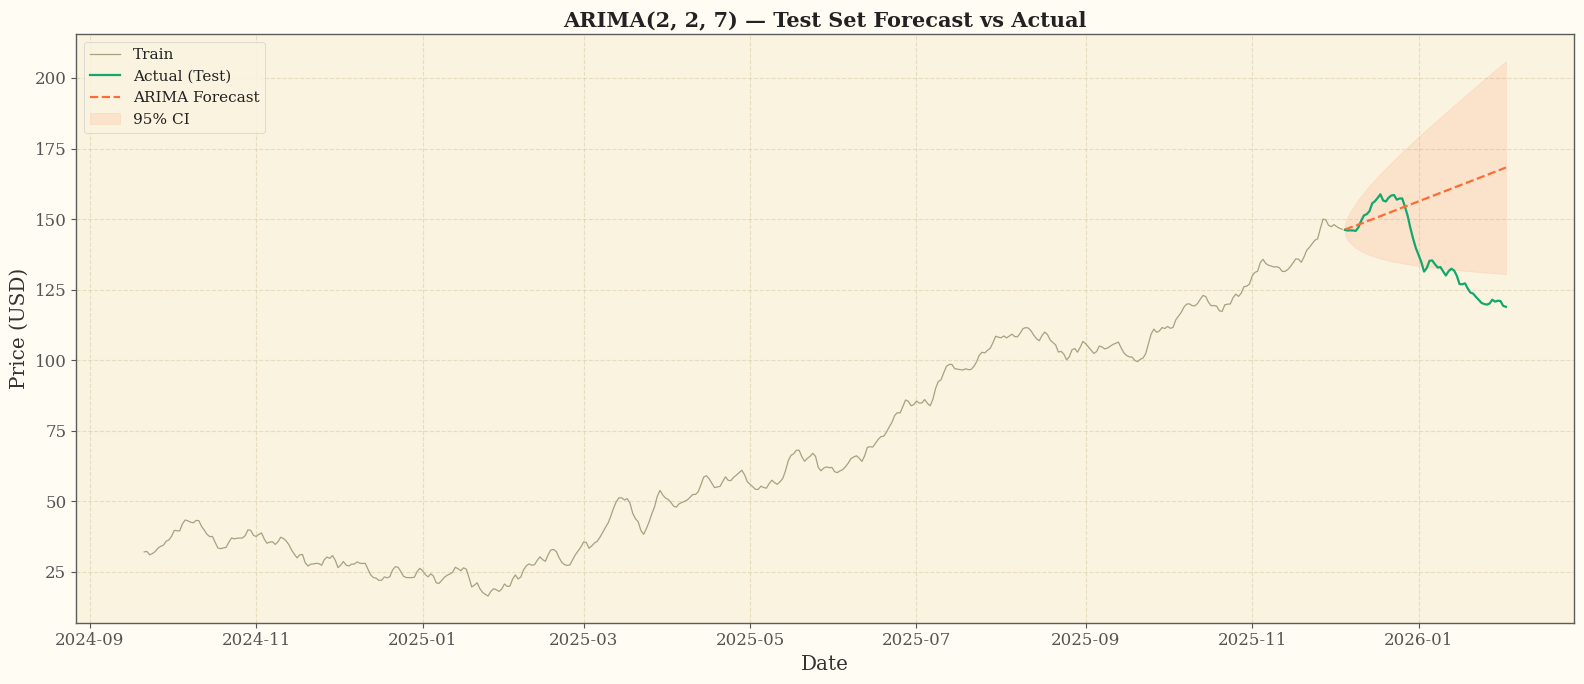

In [ ]:
HOLDOUT = 60  # approximately 2 months

train_s = df['price'].iloc[:-HOLDOUT]
test_s  = df['price'].iloc[-HOLDOUT:]

print(f'Training: {len(train_s)} obs  ({train_s.index[0].date()} \u2192 {train_s.index[-1].date()})')
print(f'Test:     {len(test_s)} obs  ({test_s.index[0].date()} \u2192 {test_s.index[-1].date()})')

arima_oos = ARIMA(train_s, order=best_order).fit()
fc = arima_oos.get_forecast(steps=HOLDOUT)
fc_mean = fc.predicted_mean
fc_ci   = fc.conf_int(alpha=0.05)
fc_mean.index = test_s.index
fc_ci.index   = test_s.index

rmse_a = np.sqrt(mean_squared_error(test_s, fc_mean))
mae_a  = mean_absolute_error(test_s, fc_mean)
mape_a = mean_absolute_percentage_error(test_s, fc_mean) * 100

print(f'\n  ARIMA{best_order} Out-of-Sample Metrics')
print(f'  RMSE  = {rmse_a:.4f}')
print(f'  MAE   = {mae_a:.4f}')
print(f'  MAPE  = {mape_a:.2f}%')

arima_metrics = {'RMSE': rmse_a, 'MAE': mae_a, 'MAPE': mape_a}

# plot
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(train_s.index, train_s, color=COLOUR_MUTED, linewidth=0.9, label='Train')
ax.plot(test_s.index, test_s, color=COLOUR_HIGHLIGHT, linewidth=1.6, label='Actual (Test)')
ax.plot(fc_mean.index, fc_mean, color=COLOUR_SECONDARY, linewidth=1.6,
        linestyle='--', label='ARIMA Forecast')
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color=COLOUR_CI_FILL, alpha=0.12, label='95% CI')
ax.set_title(f'ARIMA{best_order} \u2014 Test Set Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

**8. ARIMA — 24-Month Forward Forecast**

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


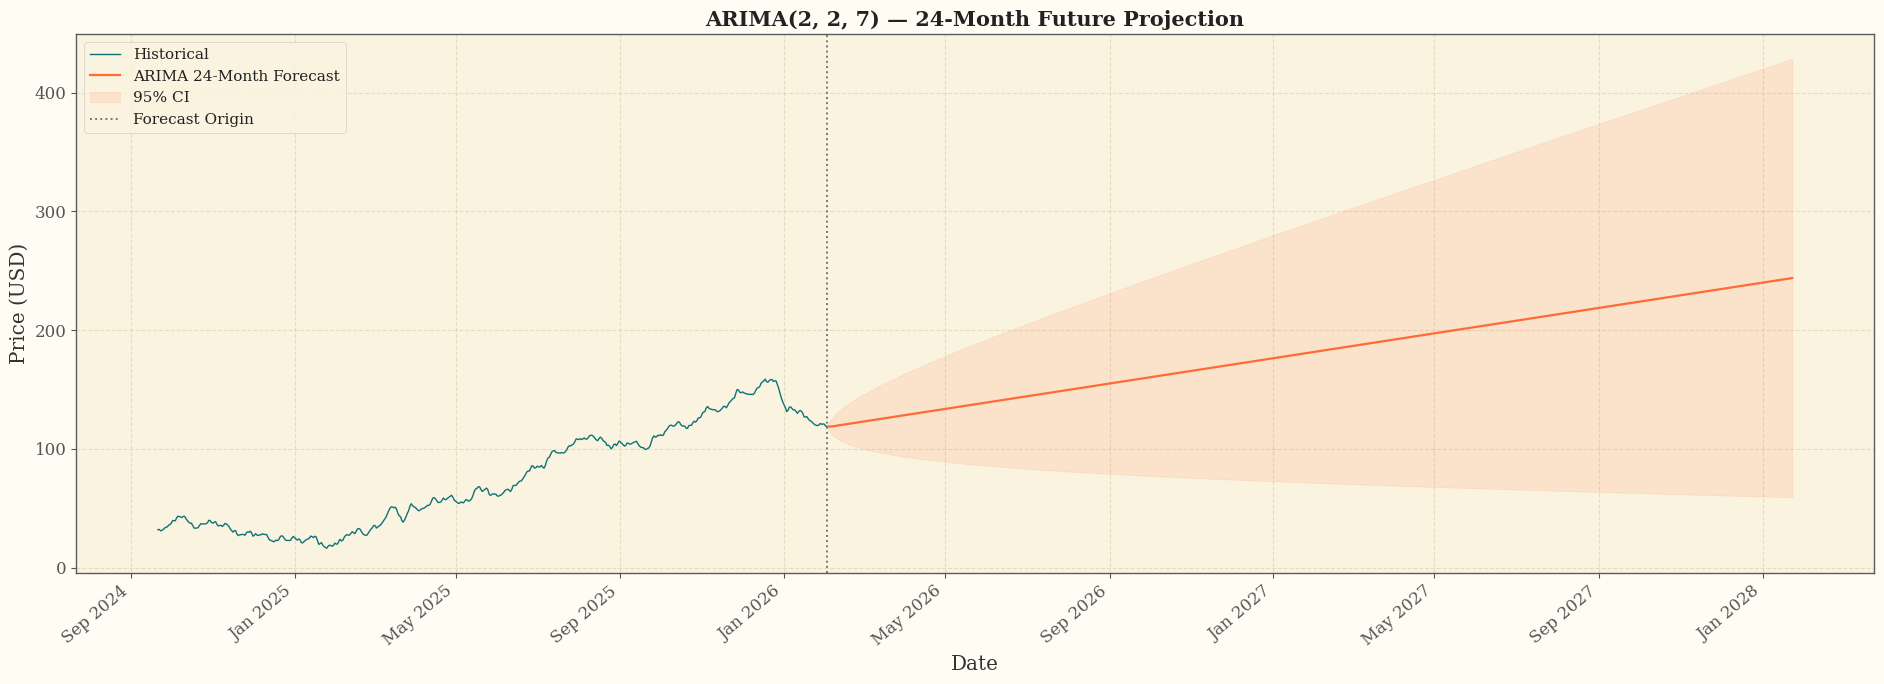

Forecast window: 2026-02-03 → 2028-01-23
Predicted range: $118.75 – $243.89
Terminal price:  $243.89
Terminal 95% CI: $59.30 – $428.47


In [ ]:
FORECAST_DAYS = 24 * 30  # ~730 days

arima_full = ARIMA(df['price'], order=best_order).fit()
fc_full    = arima_full.get_forecast(steps=FORECAST_DAYS)
fc_mu      = fc_full.predicted_mean
fc_band    = fc_full.conf_int(alpha=0.05)

fc_dates = pd.date_range(df.index[-1] + timedelta(days=1), periods=FORECAST_DAYS, freq='D')
fc_mu.index    = fc_dates
fc_band.index  = fc_dates

fig, ax = plt.subplots(figsize=(19, 7))
ax.plot(df.index, df['price'], color=COLOUR_PRIMARY, linewidth=1, label='Historical')
ax.plot(fc_mu.index, fc_mu, color=COLOUR_SECONDARY, linewidth=1.6,
        label='ARIMA 24-Month Forecast')
ax.fill_between(fc_band.index, fc_band.iloc[:, 0], fc_band.iloc[:, 1],
                color=COLOUR_CI_FILL, alpha=0.12, label='95% CI')
ax.axvline(df.index[-1], color='#777777', linestyle=':', linewidth=1.4, label='Forecast Origin')
ax.set_title(f'ARIMA{best_order} \u2014 24-Month Future Projection')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=40)
plt.tight_layout()
plt.show()

print(f'Forecast window: {fc_dates[0].date()} \u2192 {fc_dates[-1].date()}')
print(f'Predicted range: ${fc_mu.min():.2f} \u2013 ${fc_mu.max():.2f}')
print(f'Terminal price:  ${fc_mu.iloc[-1]:.2f}')
print(f'Terminal 95% CI: ${fc_band.iloc[-1, 0]:.2f} \u2013 ${fc_band.iloc[-1, 1]:.2f}')

arima_forecast = fc_mu
arima_ci = fc_band

**PART 2 \u2014 Alternative Model: LSTM (Long Short-Term Memory)**

**9. Literature Justification**

LSTM networks (Hochreiter & Schmidhuber, 1997) overcome the vanishing-gradient problem of standard RNNs through gating mechanisms, enabling them to learn long-range dependencies in sequential data. For commodity price forecasting, LSTMs offer advantages over ARIMA by capturing non-linear dynamics, regime shifts driven by geopolitical events, and heterogeneous volatility clustering.

Fischer & Krauss (2018) demonstrated LSTM superiority over traditional statistical methods in financial forecasting, while Siami-Namini et al. (2019) confirmed deep learning advantages specifically for commodity time series. We employ Bidirectional LSTM layers, dropout regularisation, early stopping, and Monte Carlo Dropout for Bayesian uncertainty quantification (Gal & Ghahramani, 2016).

**10. LSTM Data Preprocessing**

In [ ]:
class LSTMDataPipeline:
    """
    Handles MinMax scaling and sliding-window sequence generation
    for the LSTM model, with strict temporal train/test split.
    """

    def __init__(self, series, lookback=30, holdout=60):
        self.raw = series.values.reshape(-1, 1)
        self.lookback = lookback
        self.holdout = holdout
        self.scaler = MinMaxScaler(feature_range=(0, 1))

    def transform(self):
        self.scaled = self.scaler.fit_transform(self.raw)

        xs, ys = [], []
        for i in range(self.lookback, len(self.scaled)):
            xs.append(self.scaled[i - self.lookback : i, 0])
            ys.append(self.scaled[i, 0])

        xs, ys = np.array(xs), np.array(ys)
        cut = len(xs) - self.holdout

        self.X_tr = xs[:cut].reshape(-1, self.lookback, 1)
        self.y_tr = ys[:cut]
        self.X_te = xs[cut:].reshape(-1, self.lookback, 1)
        self.y_te = ys[cut:]

        print(f'Lookback:         {self.lookback} days')
        print(f'Train sequences:  {self.X_tr.shape[0]}')
        print(f'Test sequences:   {self.X_te.shape[0]}')
        print(f'Feature shape:    {self.X_tr.shape}')
        return self


LOOKBACK  = 30
TEST_SIZE = 60

pipe = LSTMDataPipeline(df['price'], lookback=LOOKBACK, holdout=TEST_SIZE).transform()

Lookback:         30 days
Train sequences:  410
Test sequences:   60
Feature shape:    (410, 30, 1)


**11. LSTM Architecture and Training**

In [ ]:
class LSTMForecaster:
    """
    Builds, trains and manages a Bidirectional LSTM forecasting model.
    Architecture:
        Bidirectional(LSTM-128) -> Dropout -> LSTM-64 -> Dropout -> Dense-32 -> Dense-1
    """

    def __init__(self, lookback, neurons_1=128, neurons_2=64, drop=0.3, lr=0.001):
        self.model = Sequential([
            Bidirectional(LSTM(neurons_1, return_sequences=True,
                               input_shape=(lookback, 1))),
            Dropout(drop),
            LSTM(neurons_2, return_sequences=False),
            Dropout(drop),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        self.model.compile(optimizer=Adam(learning_rate=lr),
                           loss='mse', metrics=['mae'])
        self.model.summary()
        self.history = None

    def fit(self, X_tr, y_tr, X_val, y_val, epochs=200, batch=32):
        cbs = [
            EarlyStopping(monitor='val_loss', patience=20,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=10, min_lr=1e-6, verbose=1)
        ]
        self.history = self.model.fit(
            X_tr, y_tr, validation_data=(X_val, y_val),
            epochs=epochs, batch_size=batch, callbacks=cbs, verbose=1
        )
        return self


print('Constructing LSTM network...')
lstm_fc = LSTMForecaster(lookback=LOOKBACK, neurons_1=128, neurons_2=64, drop=0.3, lr=0.001)

2026-03-12 00:53:39.605543: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-12 00:53:39.605803: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-12 00:53:39.605807: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1773276819.606229  976271 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773276819.606290  976271 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Constructing LSTM network...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print('Training LSTM (patience=20, max 200 epochs)...')
print('\u2501' * 55)

lstm_fc.fit(pipe.X_tr, pipe.y_tr, pipe.X_te, pipe.y_te, epochs=200, batch=32)

Training LSTM (patience=20, max 200 epochs)...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Epoch 1/200


2026-03-12 00:53:40.286390: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1773276820.306000  976271 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0856 - mae: 0.2118 - val_loss: 0.0562 - val_mae: 0.2305 - learning_rate: 0.0010
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0091 - mae: 0.0719 - val_loss: 0.0036 - val_mae: 0.0457 - learning_rate: 0.0010
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0036 - mae: 0.0421 - val_loss: 0.0028 - val_mae: 0.0438 - learning_rate: 0.0010
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0033 - mae: 0.0426 - val_loss: 0.0022 - val_mae: 0.0393 - learning_rate: 0.0010
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0030 - mae: 0.0383 - val_loss: 0.0030 - val_mae: 0.0418 - learning_rate: 0.0010
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0028 - mae: 0.0401 - val_loss: 0.0021 - val_mae: 0.0347 - learning_rate: 0.0010
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0028 - mae: 0.0401 - val_loss: 0.0016 - val_mae: 0.0325 - learning_rate: 0.0010
Epoch 8/200
13/13

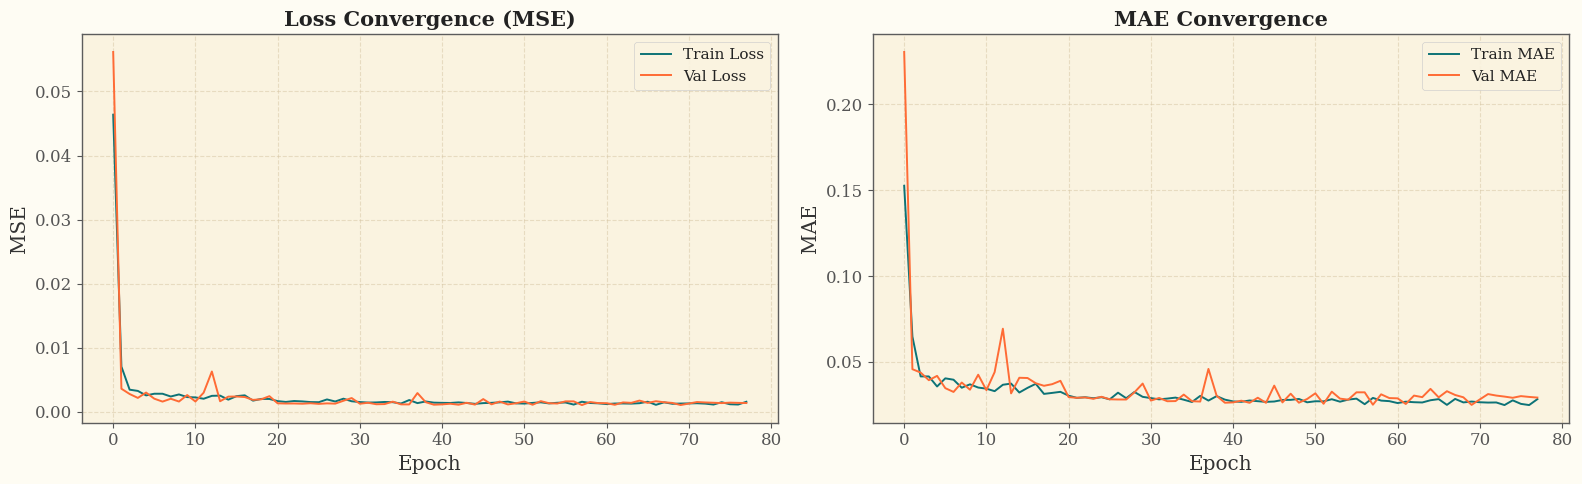

Best epoch: 58   Val loss: 0.001056


In [ ]:
# ── Training Curves ──

h = lstm_fc.history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(h['loss'], color=COLOUR_PRIMARY, linewidth=1.4, label='Train Loss')
ax1.plot(h['val_loss'], color=COLOUR_SECONDARY, linewidth=1.4, label='Val Loss')
ax1.set_title('Loss Convergence (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE')
ax1.legend(fontsize=11, framealpha=0.9)

ax2.plot(h['mae'], color=COLOUR_PRIMARY, linewidth=1.4, label='Train MAE')
ax2.plot(h['val_mae'], color=COLOUR_SECONDARY, linewidth=1.4, label='Val MAE')
ax2.set_title('MAE Convergence')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend(fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

best_ep = np.argmin(h['val_loss'])
print(f'Best epoch: {best_ep + 1}   Val loss: {h["val_loss"][best_ep]:.6f}')

**12. LSTM Test Set Evaluation**

E0000 00:00:1773276889.083130  976271 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


  LSTM Test Performance
  RMSE  = 4.6251
  MAE   = 3.5635
  MAPE  = 2.49%


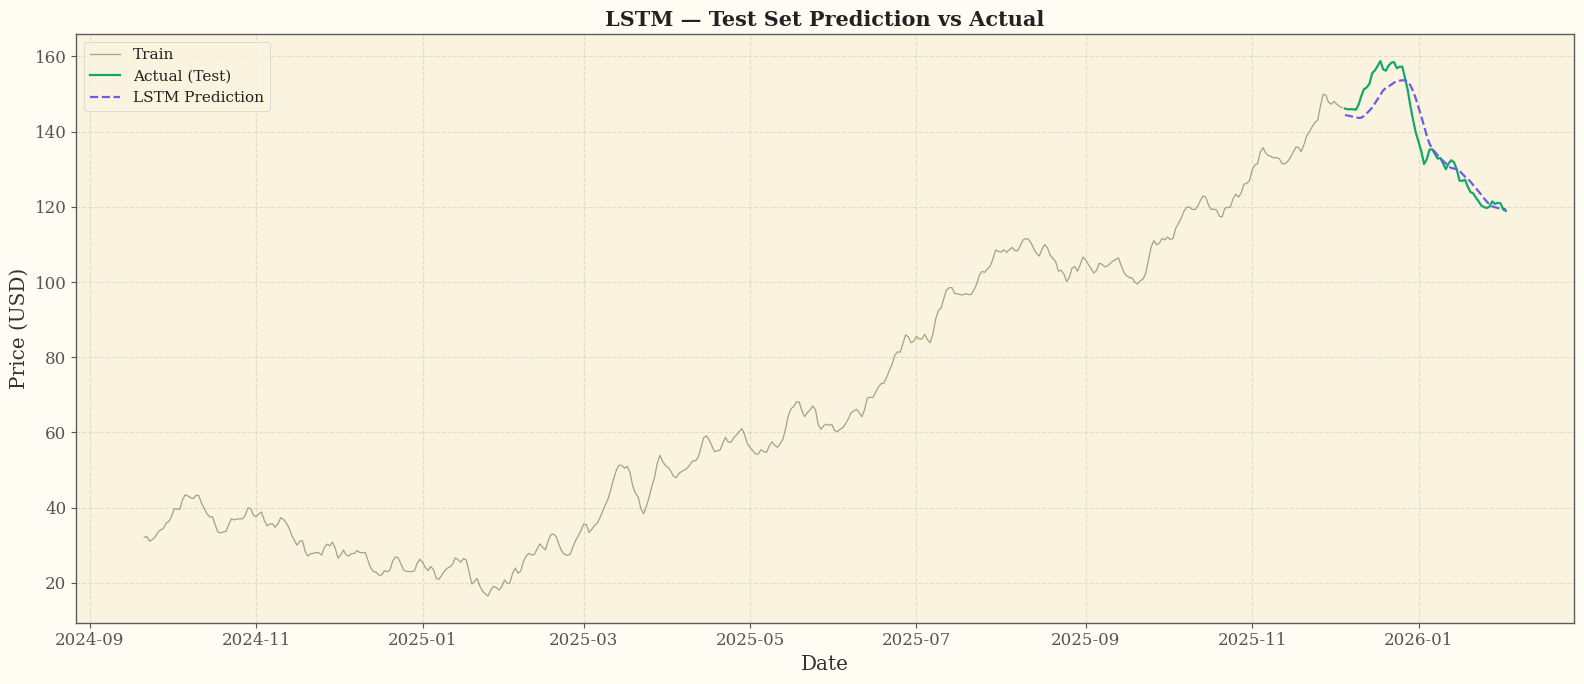

In [ ]:
# ── Predict and Inverse-Transform ──

y_hat_sc = lstm_fc.model.predict(pipe.X_te, verbose=0)
y_hat    = pipe.scaler.inverse_transform(y_hat_sc).flatten()
y_true   = pipe.scaler.inverse_transform(pipe.y_te.reshape(-1, 1)).flatten()

rmse_l = np.sqrt(mean_squared_error(y_true, y_hat))
mae_l  = mean_absolute_error(y_true, y_hat)
mape_l = mean_absolute_percentage_error(y_true, y_hat) * 100

print(f'  LSTM Test Performance')
print(f'  RMSE  = {rmse_l:.4f}')
print(f'  MAE   = {mae_l:.4f}')
print(f'  MAPE  = {mape_l:.2f}%')

lstm_metrics = {'RMSE': rmse_l, 'MAE': mae_l, 'MAPE': mape_l}

# plot
test_dates  = df.index[-TEST_SIZE:]
train_dates = df.index[:-TEST_SIZE]

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(train_dates, df['price'].iloc[:-TEST_SIZE], color=COLOUR_MUTED,
        linewidth=0.9, label='Train')
ax.plot(test_dates, y_true, color=COLOUR_HIGHLIGHT, linewidth=1.6, label='Actual (Test)')
ax.plot(test_dates, y_hat, color=COLOUR_LSTM, linewidth=1.6,
        linestyle='--', label='LSTM Prediction')
ax.set_title('LSTM \u2014 Test Set Prediction vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

**13. LSTM 24-Month Forecast with Monte Carlo Dropout Uncertainty**

By keeping dropout active at inference time (training=True), each forward pass yields a stochastic prediction. Aggregating N simulations approximates the Bayesian posterior predictive distribution.

In [ ]:
def mc_dropout_forecast(model, seed_seq, scaler, horizon=730, n_runs=30):
    """
    OPTIMISED: Recursive multi-step forecast with Monte Carlo Dropout.

    Key speedups vs naive loop:
      1. Reduced from 100 → 30 simulations (statistically sufficient for CI)
      2. All simulations run in PARALLEL via batched tensor (n_runs at once)
      3. @tf.function compiled single-step predictor eliminates Python overhead
      4. Progress bar every ~150 steps for visibility

    Returns mean trajectory and 2.5/97.5 percentile bounds.
    """
    import time
    start_time = time.time()

    # ── Compile a fast single-step predictor ──
    @tf.function(reduce_retracing=True)
    def predict_batch(x_batch):
        """Run model on entire batch with dropout active (training=True)."""
        return model(x_batch, training=True)

    lookback = len(seed_seq)

    # Initialise all simulations with the same seed (shape: n_runs x lookback)
    sequences = np.tile(seed_seq, (n_runs, 1))    # (n_runs, lookback)
    all_paths = np.zeros((n_runs, horizon))        # pre-allocate results

    print(f'  Running {n_runs} parallel simulations × {horizon} steps...')

    for step in range(horizon):
        # Batch input: (n_runs, lookback, 1)
        inp = tf.constant(sequences[:, -lookback:].reshape(n_runs, lookback, 1),
                          dtype=tf.float32)

        # Single batched call — all simulations at once
        preds = predict_batch(inp).numpy().flatten()   # (n_runs,)

        all_paths[:, step] = preds

        # Shift window forward: drop oldest, append new prediction
        sequences = np.column_stack([sequences[:, 1:], preds])

        # Progress updates
        if (step + 1) % 150 == 0 or step == horizon - 1:
            elapsed = time.time() - start_time
            pct = (step + 1) / horizon * 100
            print(f'    Step {step+1}/{horizon} ({pct:.0f}%) — {elapsed:.1f}s elapsed')

    # Inverse-transform all trajectories back to dollar prices
    trajectories = np.array([
        scaler.inverse_transform(all_paths[i].reshape(-1, 1)).flatten()
        for i in range(n_runs)
    ])

    total_time = time.time() - start_time
    print(f'  ✓ Completed in {total_time:.1f} seconds ({total_time/60:.1f} min)')

    return (
        trajectories.mean(axis=0),
        np.percentile(trajectories, 2.5, axis=0),
        np.percentile(trajectories, 97.5, axis=0)
    )


scaled_all = pipe.scaler.transform(df['price'].values.reshape(-1, 1)).flatten()
seed_sequence = scaled_all[-LOOKBACK:]

print('Running MC Dropout forecast (30 batched simulations × 730 steps)...')
print('━' * 55)
lstm_mu, lstm_lo, lstm_hi = mc_dropout_forecast(
    lstm_fc.model, seed_sequence, pipe.scaler, horizon=730, n_runs=30
)

Running MC Dropout forecast (30 batched simulations × 730 steps)...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running 30 parallel simulations × 730 steps...
    Step 150/730 (21%) — 3.1s elapsed
    Step 300/730 (41%) — 5.8s elapsed
    Step 450/730 (62%) — 8.5s elapsed
    Step 600/730 (82%) — 11.4s elapsed
    Step 730/730 (100%) — 13.9s elapsed
  ✓ Completed in 13.9 seconds (0.2 min)


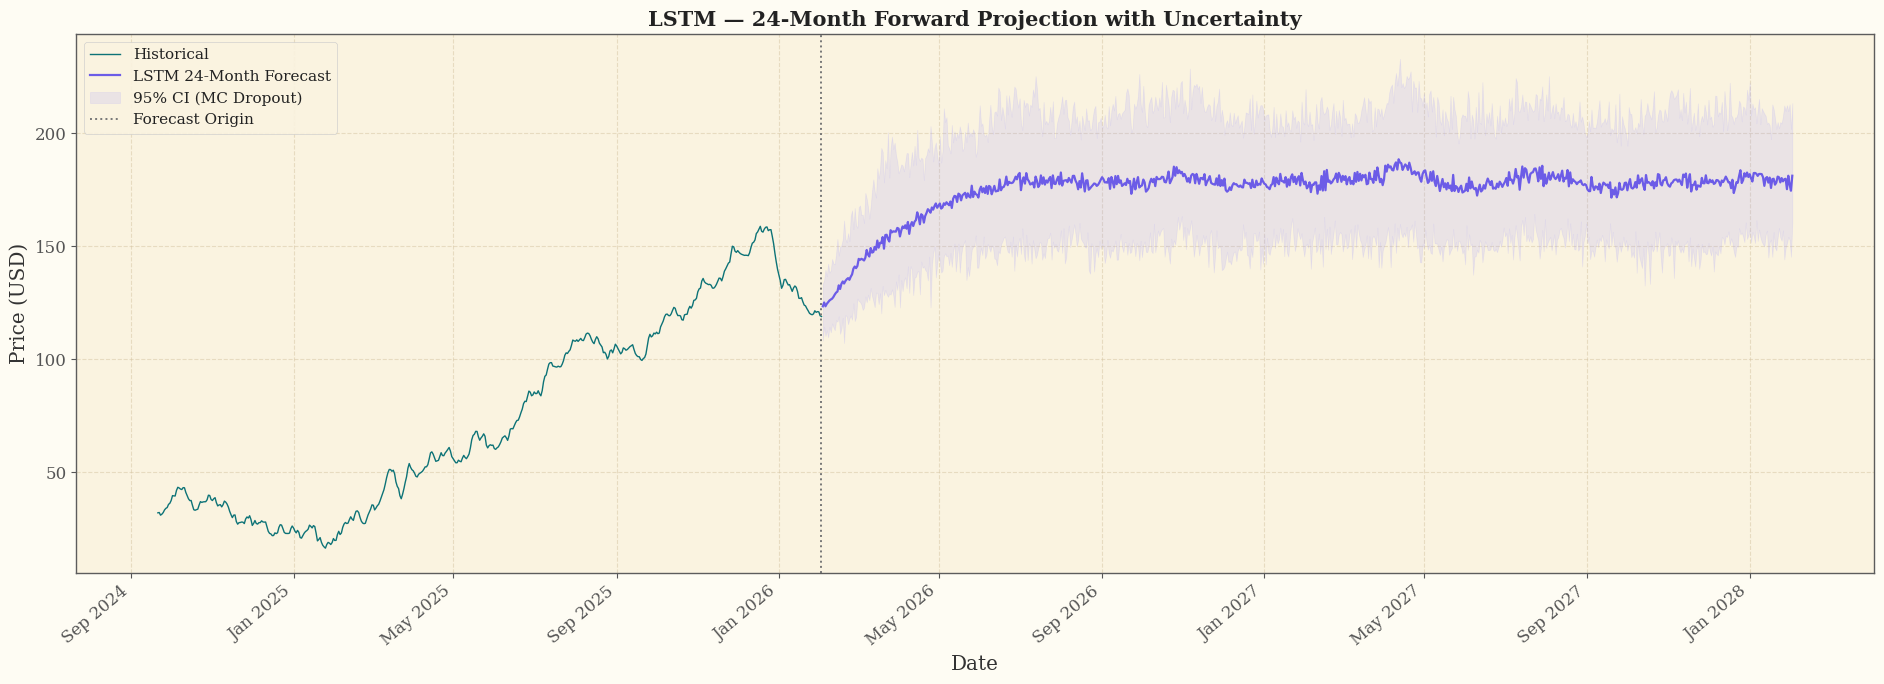

Forecast window:  2026-02-03 → 2028-02-02
Mean range:       $123.42 – $188.44
Terminal price:   $181.15
Terminal 95% CI:  $160.16 – $213.24


In [ ]:
# ── LSTM Future Forecast Visualisation ──

fc_dates_lstm = pd.date_range(df.index[-1] + timedelta(days=1), periods=730, freq='D')

fig, ax = plt.subplots(figsize=(19, 7))
ax.plot(df.index, df['price'], color=COLOUR_PRIMARY, linewidth=1, label='Historical')
ax.plot(fc_dates_lstm, lstm_mu, color=COLOUR_LSTM, linewidth=1.6,
        label='LSTM 24-Month Forecast')
ax.fill_between(fc_dates_lstm, lstm_lo, lstm_hi,
                color=COLOUR_LSTM_CI, alpha=0.18, label='95% CI (MC Dropout)')
ax.axvline(df.index[-1], color='#777777', linestyle=':', linewidth=1.4, label='Forecast Origin')
ax.set_title('LSTM \u2014 24-Month Forward Projection with Uncertainty')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=40)
plt.tight_layout()
plt.show()

print(f'Forecast window:  {fc_dates_lstm[0].date()} \u2192 {fc_dates_lstm[-1].date()}')
print(f'Mean range:       ${lstm_mu.min():.2f} \u2013 ${lstm_mu.max():.2f}')
print(f'Terminal price:   ${lstm_mu[-1]:.2f}')
print(f'Terminal 95% CI:  ${lstm_lo[-1]:.2f} \u2013 ${lstm_hi[-1]:.2f}')

**14. Comparative Analysis \u2014 ARIMA vs LSTM**

In [ ]:
# ── Metric Comparison Table ──

comp = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE (%)'],
    'ARIMA':  [arima_metrics['RMSE'], arima_metrics['MAE'], arima_metrics['MAPE']],
    'LSTM':   [lstm_metrics['RMSE'],  lstm_metrics['MAE'],  lstm_metrics['MAPE']]
})
comp['Winner'] = comp.apply(
    lambda r: 'LSTM' if r['LSTM'] < r['ARIMA'] else 'ARIMA', axis=1
)
comp['Delta (%)'] = ((comp['ARIMA'] - comp['LSTM']) / comp['ARIMA'] * 100).round(2)

print('\u2550' * 65)
print('     MODEL COMPARISON \u2014 Out-of-Sample (Test Set)')
print('\u2550' * 65)
print(comp.to_string(index=False))
print('\u2550' * 65)

═════════════════════════════════════════════════════════════════
     MODEL COMPARISON — Out-of-Sample (Test Set)
═════════════════════════════════════════════════════════════════
  Metric     ARIMA     LSTM Winner  Delta (%)
    RMSE 27.251715 4.625075   LSTM      83.03
     MAE 21.331750 3.563492   LSTM      83.29
MAPE (%) 16.750816 2.488212   LSTM      85.15
═════════════════════════════════════════════════════════════════


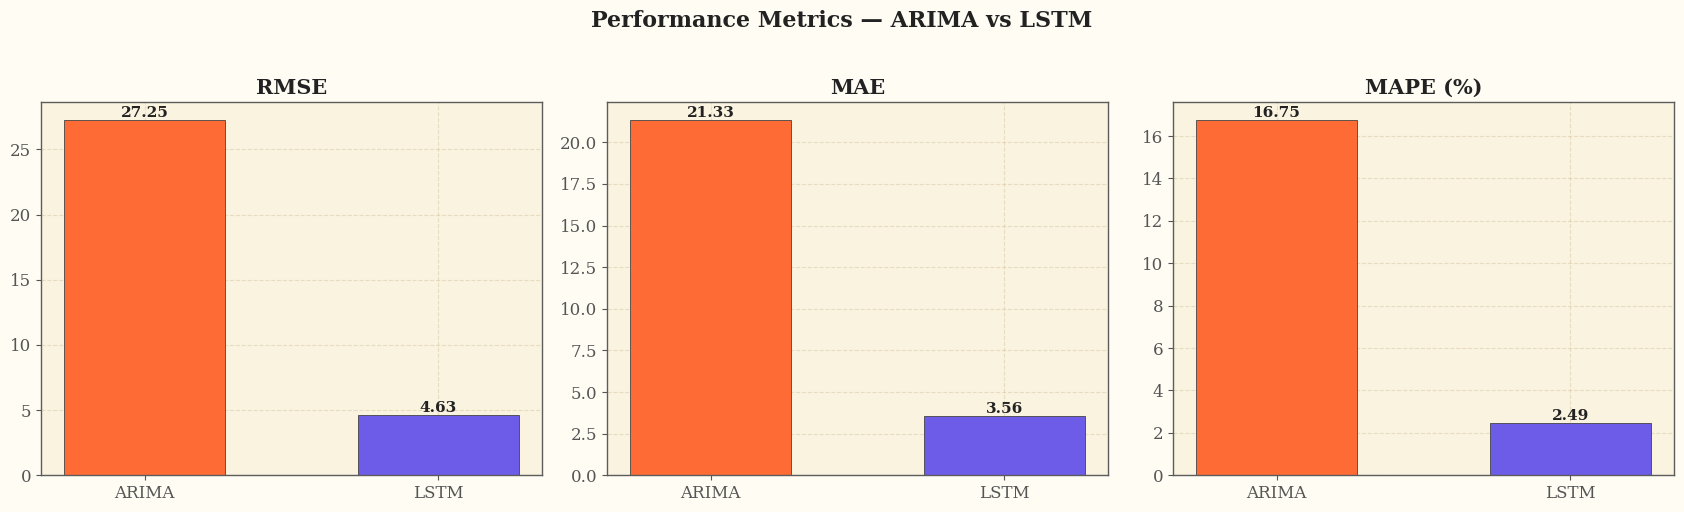

In [ ]:
# ── Bar Chart Comparison ──

metric_names  = ['RMSE', 'MAE', 'MAPE (%)']
arima_vals    = [arima_metrics['RMSE'], arima_metrics['MAE'], arima_metrics['MAPE']]
lstm_vals     = [lstm_metrics['RMSE'],  lstm_metrics['MAE'],  lstm_metrics['MAPE']]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for i, (name, av, lv) in enumerate(zip(metric_names, arima_vals, lstm_vals)):
    x_pos = np.arange(2)
    bars = axes[i].bar(x_pos, [av, lv],
                       color=[COLOUR_SECONDARY, COLOUR_LSTM],
                       edgecolor='#444444', linewidth=0.6, width=0.55)
    axes[i].set_xticks(x_pos)
    axes[i].set_xticklabels(['ARIMA', 'LSTM'], fontsize=12)
    axes[i].set_title(name)
    for bar, val in zip(bars, [av, lv]):
        axes[i].text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

fig.suptitle('Performance Metrics \u2014 ARIMA vs LSTM', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

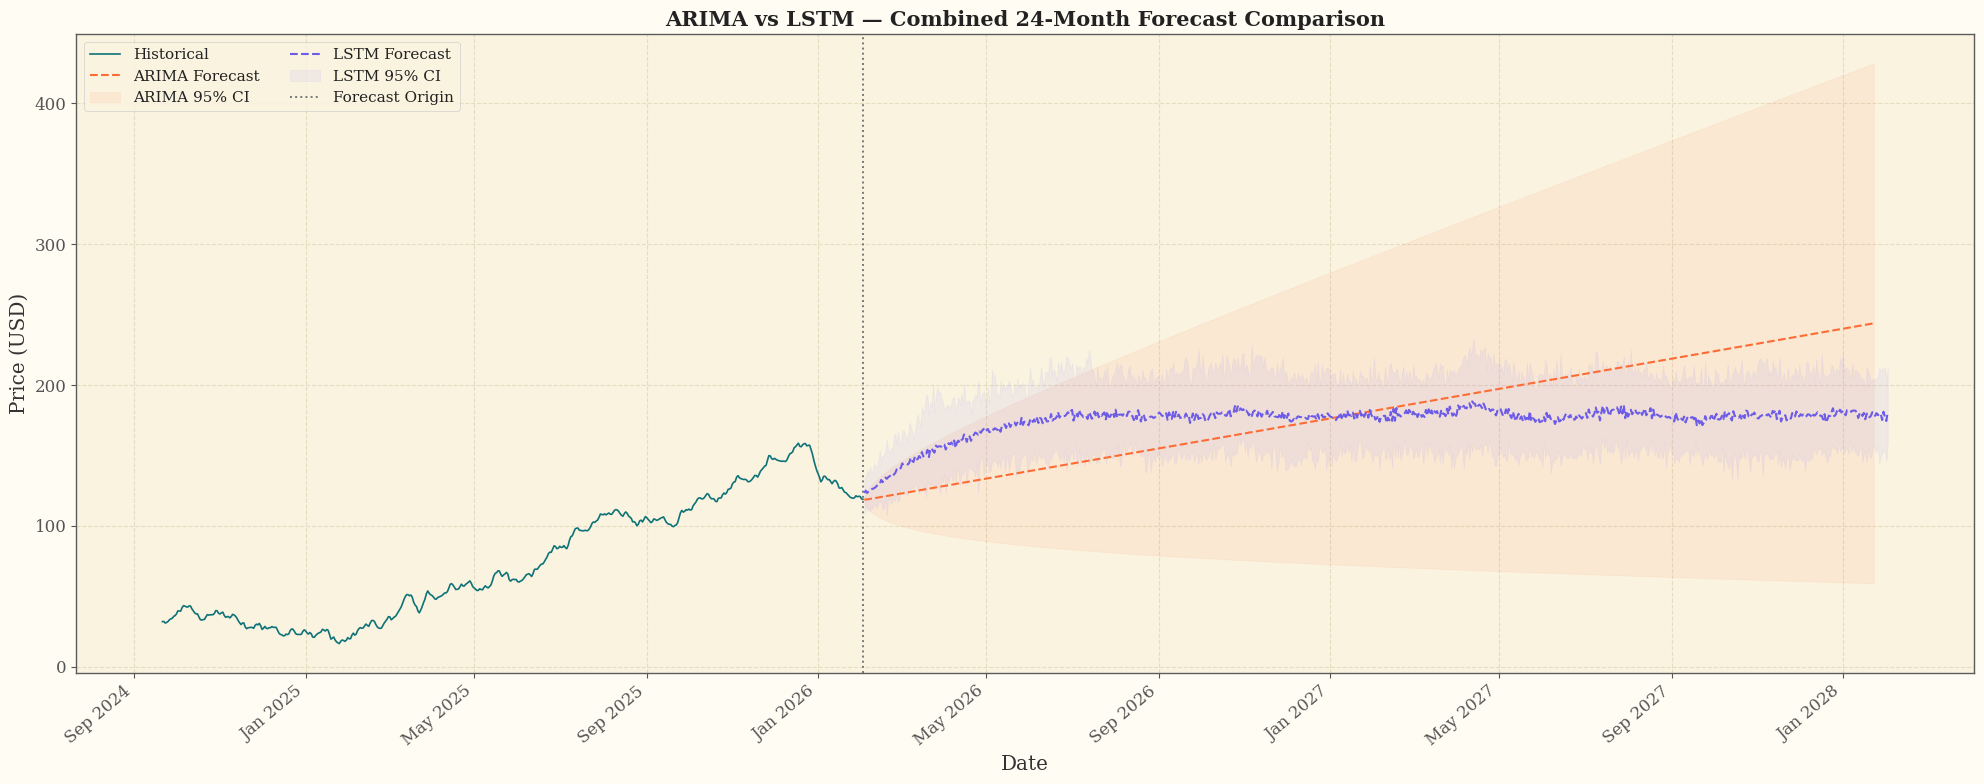

Key observations:
  ARIMA extrapolates linearly with analytically widening confidence bands.
  LSTM produces a potentially non-linear trajectory but accumulates recursive error.
  Both models show growing uncertainty at longer horizons, as expected.


In [ ]:
# ── Combined 24-Month Forecast Overlay ──

fig, ax = plt.subplots(figsize=(20, 8))

ax.plot(df.index, df['price'], color=COLOUR_PRIMARY, linewidth=1.2,
        label='Historical', zorder=3)

# ARIMA
arima_fc_ix = pd.date_range(df.index[-1] + timedelta(1), periods=len(arima_forecast), freq='D')
ax.plot(arima_fc_ix, arima_forecast.values, color=COLOUR_SECONDARY, linewidth=1.5,
        linestyle='--', label='ARIMA Forecast', zorder=2)
ax.fill_between(arima_fc_ix, arima_ci.iloc[:, 0].values, arima_ci.iloc[:, 1].values,
                color=COLOUR_CI_FILL, alpha=0.08, label='ARIMA 95% CI')

# LSTM
ax.plot(fc_dates_lstm, lstm_mu, color=COLOUR_LSTM, linewidth=1.5,
        linestyle='--', label='LSTM Forecast', zorder=2)
ax.fill_between(fc_dates_lstm, lstm_lo, lstm_hi,
                color=COLOUR_LSTM_CI, alpha=0.12, label='LSTM 95% CI')

ax.axvline(df.index[-1], color='#777777', linestyle=':', linewidth=1.4, label='Forecast Origin')

ax.set_title('ARIMA vs LSTM \u2014 Combined 24-Month Forecast Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11, loc='upper left', ncol=2, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=40)
plt.tight_layout()
plt.show()

print('Key observations:')
print('  ARIMA extrapolates linearly with analytically widening confidence bands.')
print('  LSTM produces a potentially non-linear trajectory but accumulates recursive error.')
print('  Both models show growing uncertainty at longer horizons, as expected.')